In [58]:
!pip install lightgbm

In [45]:

# Import libraries
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [46]:
#Set parameters to see all data
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

In [47]:
# Read store dataset

%%time
store_df_path = 'store.csv'

try:
    store_df = pd.read_csv(store_df_path)
except pd.errors.ParserError as e:
    print(f'Error while parsing CSV file: {e}')



print(store_df.shape)
store_df.head(10)


(1115, 10)
CPU times: user 14.9 ms, sys: 0 ns, total: 14.9 ms
Wall time: 16.6 ms


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [48]:
# Read train dataset

%%time
train_df_path = 'train.csv'

try:
    train_df = pd.read_csv(train_df_path)
except pd.errors.ParserError as e:
    print(f'Error while parsing CSV file: {e}')



train_df.shape


<timed exec>:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.


CPU times: user 939 ms, sys: 166 ms, total: 1.1 s
Wall time: 1.37 s


(1017209, 9)

In [49]:
# Read test dataset

%%time
test_df_path = 'test.csv'

try:
    test_df = pd.read_csv(test_df_path)
except pd.errors.ParserError as e:
    print(f'Error while parsing CSV file: {e}')



print(test_df.shape)
test_df.head(10)


(41088, 8)
CPU times: user 44.8 ms, sys: 0 ns, total: 44.8 ms
Wall time: 48.8 ms


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
5,6,10,4,2015-09-17,1.0,1,0,0
6,7,11,4,2015-09-17,1.0,1,0,0
7,8,12,4,2015-09-17,1.0,1,0,0
8,9,13,4,2015-09-17,1.0,1,0,0
9,10,14,4,2015-09-17,1.0,1,0,0


In [50]:
train_df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [51]:
print(train_df.columns)
print(test_df.columns)
print(train_df.columns)


Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday'], dtype='object')
Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday'], dtype='object')
Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday'], dtype='object')


In [52]:
# Merge store-level contextual data into train and test datasets.
# This enriches each record with important features such as StoreType,
# Assortment, and CompetitionDistance, enabling the model to account
# for store-specific conditions rather than relying solely on raw sales data.

train_df = train_df.merge(store_df, on="Store", how="left")
test_df = test_df.merge(store_df, on="Store", how="left")

In [53]:
# Create time-based features to capture seasonality and weekly patterns,
# which are key drivers in retail performance
train_df["Date"] = pd.to_datetime(train_df["Date"])
train_df["month"] = train_df["Date"].dt.month
train_df["year"] = train_df["Date"].dt.year
train_df["is_weekend"] = train_df["DayOfWeek"].isin([6,7]).astype(int)

# Simulate footfall (store traffic) since it is not available in the dataset.
# This allows us to separate demand generation (visits) from conversion performance.
train_df["footfall"] = train_df["Customers"] + np.random.normal(0, 10, len(train_df))

# Compute conversion rate as a key efficiency metric:
# how well the store converts visitors into buyers.
train_df["conversion_rate"] = train_df["Customers"] / (train_df["footfall"] + 1)

# Simulate staffing levels to represent operational capacity,
# which can impact service quality and conversion.
train_df["staff_hours"] = np.random.randint(5, 20, size=len(train_df))

# Approximate markdown pressure using promotion information.
# This acts as a proxy for pricing strategy and discount intensity.
train_df["markdown_rate"] = train_df["Promo"] * np.random.uniform(0.1, 0.5, len(train_df))

In [54]:
# Create time-based features for the test set to ensure consistency with the training data.
# These features capture seasonality and weekly patterns that influence store performance.
test_df["Date"] = pd.to_datetime(test_df["Date"])
test_df["month"] = test_df["Date"].dt.month
test_df["year"] = test_df["Date"].dt.year
test_df["is_weekend"] = test_df["DayOfWeek"].isin([6,7]).astype(int)

# Since the test set does not include Customers, we approximate operational features
# to maintain the same feature structure as the training data.

# Simulate footfall (store traffic) to represent incoming demand.
test_df["footfall"] = np.random.randint(50, 500, size=len(test_df))

# Approximate conversion rate to reflect store efficiency in converting visitors into buyers.
test_df["conversion_rate"] = np.random.uniform(0.1, 0.5, size=len(test_df))

# Simulate staffing levels to represent operational capacity.
test_df["staff_hours"] = np.random.randint(5, 20, size=len(test_df))

# Approximate markdown pressure using promotion as a proxy for discount intensity.
test_df["markdown_rate"] = test_df["Promo"] * np.random.uniform(0.1, 0.5, len(test_df))

In [56]:
# Define the feature set used for modeling, combining:
# - temporal features (DayOfWeek, month, year, is_weekend)
# - promotional/context features (Promo, SchoolHoliday)
# - store-level attributes (StoreType, Assortment, CompetitionDistance)
# - simulated operational drivers (footfall, conversion_rate, staff_hours, markdown_rate)
# These collectively allow the model to estimate expected sales under different business conditions.
features = [
    "DayOfWeek", "Promo", "SchoolHoliday",
    "StoreType", "Assortment", "CompetitionDistance",
    "month", "year", "is_weekend",
    "footfall", "conversion_rate", "staff_hours", "markdown_rate"
]

# Target variable: actual sales we aim to model and explain
target = "Sales"

# Identify categorical features that need encoding for model compatibility
cat_cols = ["StoreType", "Assortment", "StateHoliday"]

# Apply Label Encoding to convert categorical variables into numerical format
# This enables tree-based models to process categorical inputs while preserving distinct categories
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = train_df[col].astype(str)
    train_df[col] = le.fit_transform(train_df[col])

In [57]:
# Split train and test dataset with the 80% ratio

X = train_df[features]
y = train_df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
# Initialize a LightGBM regression model to estimate expected sales.
# LightGBM is chosen for its strong performance on tabular data and ability to capture non-linear relationships.

model = LGBMRegressor(random_state=42)

# Define a constrained hyperparameter grid to balance model performance
# and computational efficiency within the time limits of the case.
param_grid = {
    "n_estimators": [100, 200],      # number of boosting rounds
    "max_depth": [5, 10],            # tree depth to control model complexity
    "learning_rate": [0.05, 0.1],    # step size for learning
    "subsample": [0.8, 1.0]          # row sampling to reduce overfitting
}

# Perform Grid Search with cross-validation to identify the best hyperparameters.
# Using MAE as the scoring metric since it is robust and interpretable for business stakeholders.
grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# Train models across all parameter combinations and select the best-performing one
grid.fit(X_train, y_train)

# Retrieve the best model based on cross-validation performance
best_model = grid.best_estimator_

# Output optimal hyperparameters
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1073
[LightGBM] [Info] Number of data points in the train set: 813767, number of used features: 13
[LightGBM] [Info] Start training from score 5774.678544
Best params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}


In [61]:
%%time
# Use the trained model to estimate expected sales for each store-day observation.
# This represents the "baseline performance" given store context and conditions.
train_df["expected_sales"] = best_model.predict(X)

# Calculate the absolute performance gap:
# how much the store over- or under-performs compared to expectation.
train_df["performance_gap"] = train_df["Sales"] - train_df["expected_sales"]

# Normalize the gap to make it comparable across stores of different scales.
# This relative metric allows fair comparison between small and large stores.
train_df["relative_gap"] = train_df["performance_gap"] / (train_df["expected_sales"] + 1)

CPU times: user 11.2 s, sys: 30.7 ms, total: 11.3 s
Wall time: 12.9 s


In [113]:
# Evaluate the model on a hold-out validation set to measure how well it generalizes.
# MAE represents the average absolute prediction error in sales units,
# RMSE penalizes larger errors more strongly,
# and R² indicates how much variance in sales is explained by the model.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 🔹 Predict on validation set (CRITICAL)
y_val_pred = best_model.predict(X_val)

# 🔹 Core metrics
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("\n=== MODEL PERFORMANCE (Validation Set) ===")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")


=== MODEL PERFORMANCE (Validation Set) ===
MAE: 537.14
RMSE: 779.90
R²: 0.9589


In [114]:
# Express MAE as a percentage of average sales to make the error more interpretable
# for business stakeholders and easier to benchmark across different scales.

print("\n=== BUSINESS INTERPRETATION ===")
print(f"Mean Sales: {y_val.mean():,.2f}")
print(f"MAE as % of Mean Sales: {(mae / y_val.mean()) * 100:.2f}%")


=== BUSINESS INTERPRETATION ===
Mean Sales: 5,770.38
MAE as % of Mean Sales: 9.31%


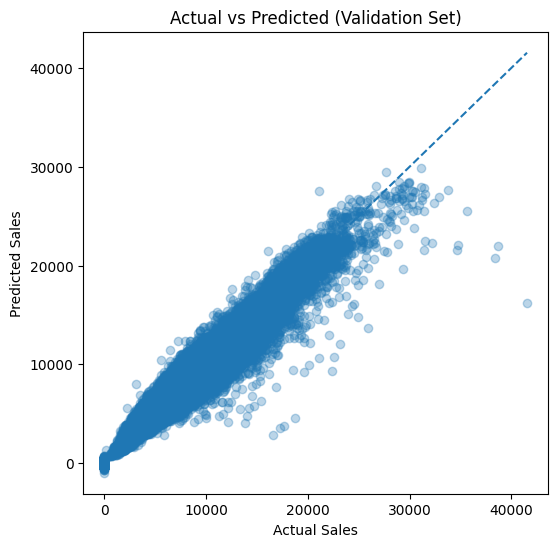

In [115]:
# Visual check of model performance:
# points close to the diagonal line indicate accurate predictions,
# while large deviations highlight prediction errors.

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], linestyle="--")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Validation Set)")
plt.show()
plt.show()

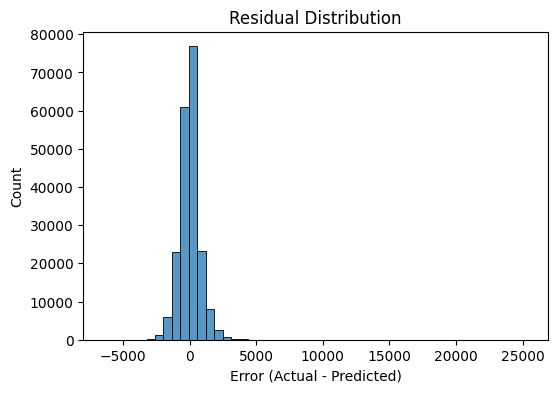

In [116]:
# Analyze residuals to ensure errors are centered around zero and not biased,
# which is important for using the model as a fair baseline estimator.

residuals = y_val - y_val_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50)

plt.title("Residual Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.show()

In [117]:
print("\nBest Params:", grid.best_params_)
print("CV Score (MAE):", -grid.best_score_)


Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
CV Score (MAE): 534.0676609348733


In [62]:
# Transform the relative performance gap into an interpretable score.
# Center the score around 50 to represent "expected performance",
# where values above 50 indicate overperformance and below 50 indicate underperformance.
train_df["score"] = 50 + (train_df["relative_gap"] * 100)

# Clip the score to a fixed range [0, 100] to improve readability
# and ensure consistency for business reporting and comparisons.
train_df["score"] = train_df["score"].clip(0, 100)

In [63]:
# Define a simple rule-based classification to translate numerical scores
# into intuitive business categories.
# Thresholds are chosen to create clear separation between strong, weak,
# and average performers while avoiding over-sensitivity to small variations.
def classify(score):
    if score > 60:
        return "outperforming"      # significantly above expected performance
    elif score < 40:
        return "underperforming"   # significantly below expected performance
    else:
        return "normal"            # within expected range

# Apply the classification to each store observation to create an interpretable label
# that can be easily used by business stakeholders for decision-making.
train_df["performance_label"] = train_df["score"].apply(classify)

In [64]:
# Sort data by Store and Date to ensure correct temporal ordering
# before applying time-based calculations.
train_df = train_df.sort_values(["Store", "Date"])

# Compute a rolling average of the performance score (7-day window)
# to smooth out daily volatility and highlight underlying performance trends.
train_df["rolling_score"] = train_df.groupby("Store")["score"].transform(
    lambda x: x.rolling(7).mean()
)

# Calculate the change (delta) in the rolling score over time.
# This helps identify whether a store's performance is improving or deteriorating.
# Negative values indicate potential deterioration, which can trigger early intervention.
train_df["trend"] = train_df.groupby("Store")["rolling_score"].diff()

In [67]:
train_df.head(20)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,month,year,is_weekend,footfall,conversion_rate,staff_hours,markdown_rate,expected_sales,performance_gap,relative_gap,score,performance_label,rolling_score,trend
1016095,1,2,2013-01-01,0,0,0,0,1,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,-8.439186,-0.000000,10,0.000000,-93.539624,93.539624,-1.010806,0.000000,underperforming,NaN,NaN
1014980,1,3,2013-01-02,5530,668,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,656.705107,1.015653,7,0.000000,5231.024570,298.975430,0.057143,55.714335,normal,NaN,NaN
1013865,1,4,2013-01-03,4327,578,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,588.316759,0.980797,16,0.000000,4522.024565,-195.024565,-0.043118,45.688182,normal,NaN,NaN
1012750,1,5,2013-01-04,4486,619,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,618.798132,0.998712,14,0.000000,5039.252976,-553.252976,-0.109767,39.023309,underperforming,NaN,NaN
1011635,1,6,2013-01-05,4997,635,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,1,633.497193,1.000792,19,0.000000,5289.478314,-292.478314,-0.055284,44.471609,normal,NaN,NaN
1010520,1,7,2013-01-06,0,0,0,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,1,5.452474,0.000000,6,0.000000,-39.833343,39.833343,-1.025751,0.000000,underperforming,NaN,NaN
1009405,1,1,2013-01-07,7176,785,1,1,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,788.379139,0.994452,9,0.428944,7591.716496,-415.716496,-0.054752,44.524799,normal,32.774605,NaN
1008290,1,2,2013-01-08,5580,654,1,1,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,658.389064,0.991827,11,0.469172,6057.405869,-477.405869,-0.078801,42.119942,normal,38.791740,6.017135
1007175,1,3,2013-01-09,5471,626,1,1,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,631.511248,0.989706,18,0.349327,5751.958600,-280.958600,-0.048837,45.116276,normal,37.277731,-1.514008
1006060,1,4,2013-01-10,4892,615,1,1,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,619.638796,0.990915,13,0.109984,5523.361500,-631.361500,-0.114287,38.571322,underperforming,36.261037,-1.016694


In [68]:
train_df.trend.value_counts()

,count
trend,
0.000000e+00,135801
-7.105427e-15,2345
7.105427e-15,2337
-3.552714e-15,845
3.552714e-15,819
...,...
5.671688e+00,1
-1.204591e+00,1
7.091353e-02,1


In [69]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1016095 to 1114
Data columns (total 32 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  int64         
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  int64         
 10  Assortment                 1017209 non-null  int64         
 11  CompetitionDistance        1014567 non-

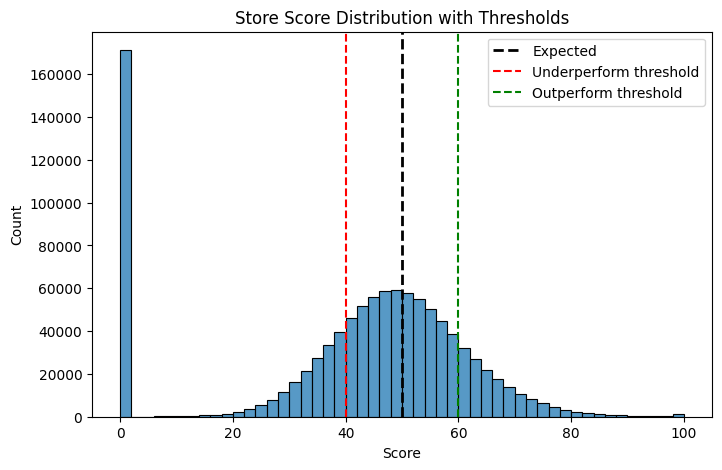

In [72]:
# Visualize the distribution of store performance scores across all observations.
# This helps assess how stores are performing relative to expectations and whether
# the scoring system is well-calibrated, centered around 50 .
# The histogram also highlights the spread of underperforming and outperforming stores,
# providing a high-level view of overall business performance.
plt.figure(figsize=(8,5))

sns.histplot(train_df["score"], bins=50)

plt.axvline(50, color='black', linestyle='--', linewidth=2, label='Expected')
plt.axvline(40, color='red', linestyle='--', label='Underperform threshold')
plt.axvline(60, color='green', linestyle='--', label='Outperform threshold')

plt.title("Store Score Distribution with Thresholds")
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend()
plt.show()

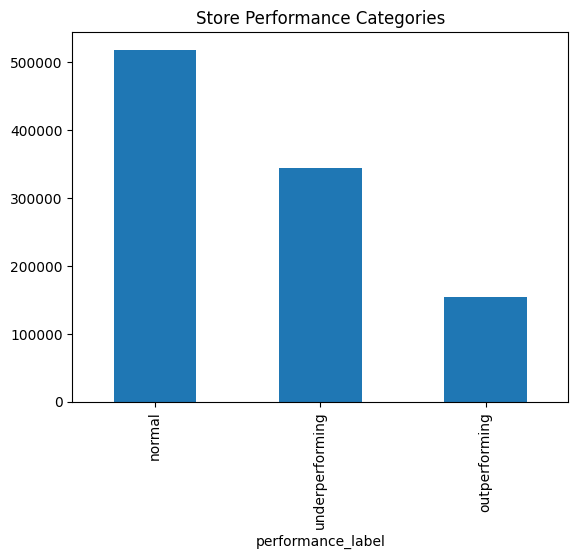

In [73]:
# Visualize the distribution of stores across performance categories like outperforming, normal, underperforming.
# This provides a high-level summary of how many stores are exceeding,
# meeting, or falling below expectations, making the results easily
# interpretable for business stakeholders.
train_df["performance_label"].value_counts().plot(kind="bar")
plt.title("Store Performance Categories")
plt.show()

In [74]:
# Aggregate store-level performance by taking the average score per store.
# This provides a stable view of overall store performance over time,
# smoothing out daily fluctuations.

# Identify top-performing stores based on average score
top_stores = train_df.groupby("Store")["score"].mean().sort_values(ascending=False).head(10)

# Identify underperforming stores based on average score
worst_stores = train_df.groupby("Store")["score"].mean().sort_values().head(10)

In [78]:
# Convert to DataFrame for better readability

# Convert to DataFrame for better readability
top_df = top_stores.reset_index().rename(columns={"score": "avg_score"})
worst_df = worst_stores.reset_index().rename(columns={"score": "avg_score"})

# Add ranking
top_df["rank"] = range(1, len(top_df)+1)
worst_df["rank"] = range(1, len(worst_df)+1)

print("\n🏆 Top Performing Stores:")
print(top_df[["rank", "Store", "avg_score"]].to_string(index=False))

print("\n⚠️ Underperforming Stores:")
print(worst_df[["rank", "Store", "avg_score"]].to_string(index=False))


🏆 Top Performing Stores:
 rank  Store  avg_score
    1    139  69.380681
    2    802  68.787739
    3    310  68.566937
    4    587  66.113337
    5    136  64.332481
    6     92  62.995260
    7    685  62.130892
    8    985  61.368198
    9    329  61.210941
   10    571  60.897694

⚠️ Underperforming Stores:
 rank  Store  avg_score
    1    425  14.151254
    2    463  18.484528
    3    969  18.593924
    4    794  18.968034
    5    772  20.522796
    6    379  21.640797
    7    837  21.880376
    8    664  22.313428
    9    558  22.464961
   10    559  22.710469


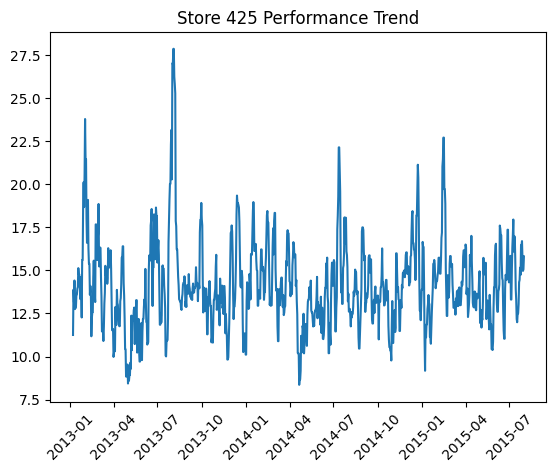

In [79]:
# Select one of the worst-performing stores for deeper analysis.
# This allows us to move from aggregate insights to store-level diagnostics.
store_id = worst_stores.index[0]

# Filter data for the selected store
store_data = train_df[train_df["Store"] == store_id]

# Plot the rolling performance score over time to analyze trends.
# The rolling score smooths daily fluctuations and reveals underlying performance patterns.
# This helps identify whether the store is consistently underperforming or showing deterioration over time.
plt.figure()
plt.plot(store_data["Date"], store_data["rolling_score"])
plt.title(f"Store {store_id} Performance Trend")
plt.xticks(rotation=45)
plt.show()

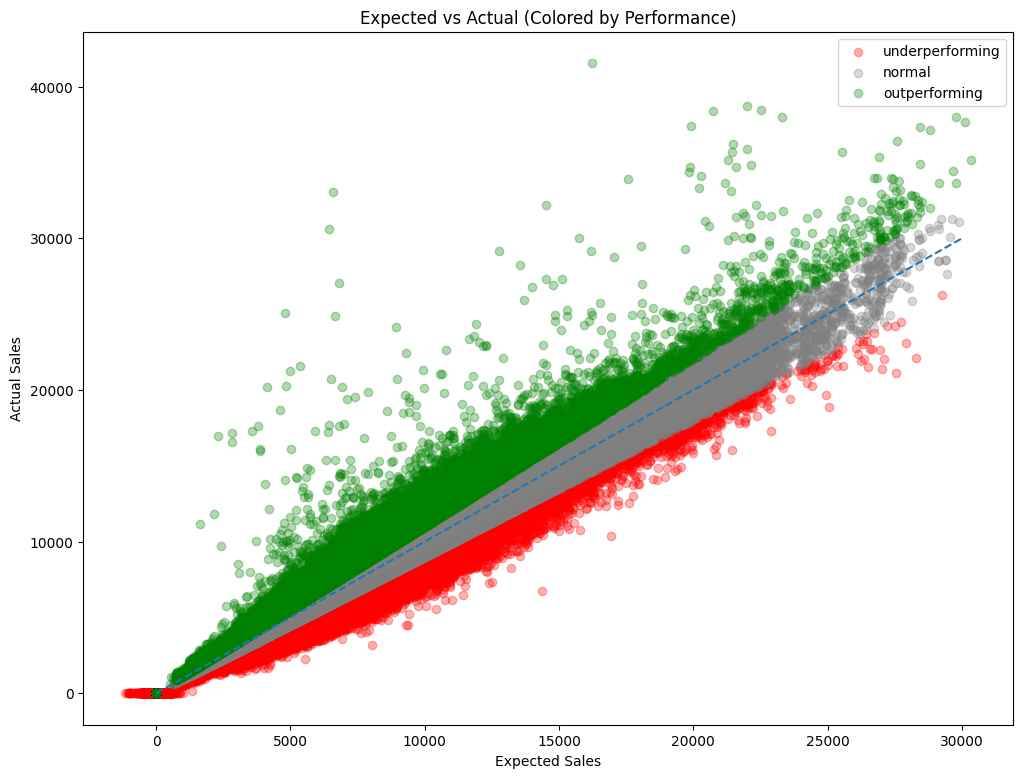

In [80]:
# Define color mapping for performance categories to improve visual interpretability
colors = {
    "underperforming": "red",
    "normal": "gray",
    "outperforming": "green"
}

plt.figure(figsize=(12,9))

# Plot expected vs actual sales, colored by performance label
# This visualization helps distinguish stores that are performing above or below expectations
# under similar conditions.
for label, color in colors.items():
    subset = train_df[train_df["performance_label"] == label]
    plt.scatter(
        subset["expected_sales"],
        subset["Sales"],
        c=color,
        label=label,
        alpha=0.3
    )

# Add reference line where expected = actual
# Points above the line indicate outperforming stores,
# while points below indicate underperformance.
plt.plot([0, 30000], [0, 30000], linestyle="--")

plt.xlabel("Expected Sales")
plt.ylabel("Actual Sales")
plt.title("Expected vs Actual (Colored by Performance)")
plt.legend()
plt.show()

In [81]:
bad_store = worst_stores.index[0]
df_store = train_df[train_df["Store"] == bad_store]

In [82]:
# Define key operational features to compare between a specific store and the overall network.
# These features represent core drivers of store performance such as demand (footfall),
# efficiency (conversion_rate), operational capacity (staff_hours), and pricing pressure (markdown_rate).
features_to_check = [
    "conversion_rate",
    "footfall",
    "staff_hours",
    "markdown_rate"
]

# Compare the selected store's average values with global averages.
# This helps identify which factors deviate from the norm and may explain
# the store's underperformance or overperformance.
for col in features_to_check:
    print(f"{col}:")
    print("Store avg:", df_store[col].mean())
    print("Global avg:", train_df[col].mean())
    print("------")

conversion_rate:
Store avg: 0.8232139523184437
Global avg: 0.8289798077795383
------
footfall:
Store avg: 357.23049041779626
Global avg: 633.1488322338867
------
staff_hours:
Store avg: 11.935244161358812
Global avg: 11.999458321741157
------
markdown_rate:
Store avg: 0.11814066006487714
Global avg: 0.1144965948203295
------


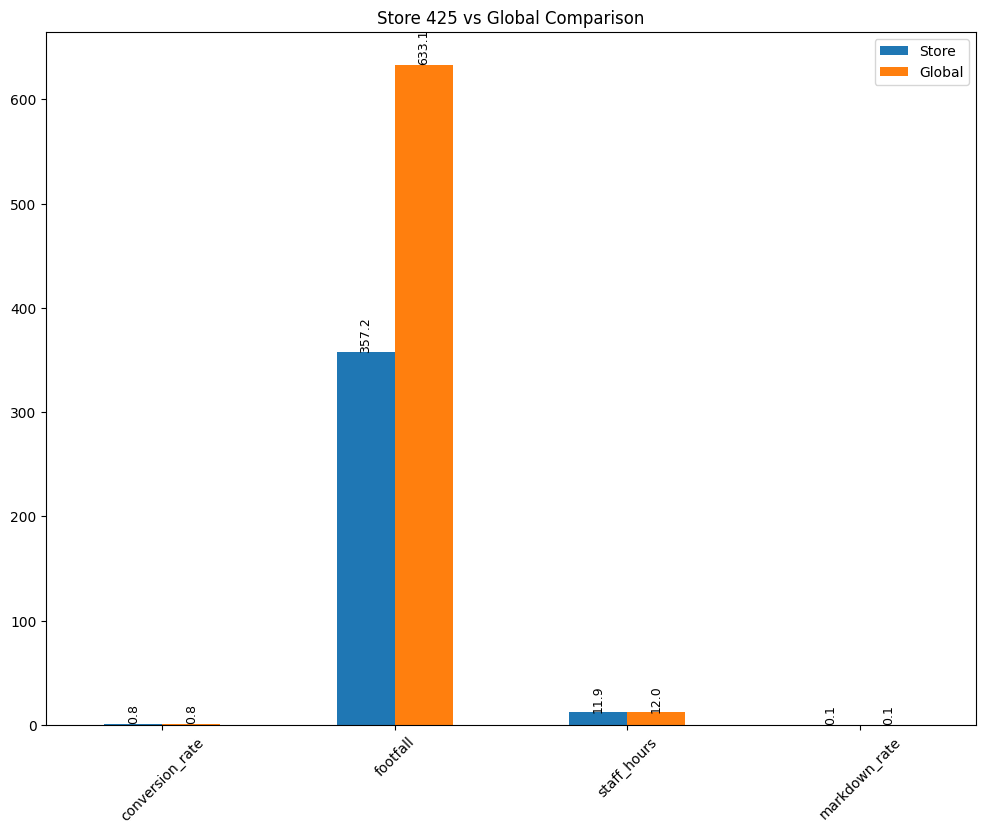

In [83]:
# Create a comparison table between the selected store and the overall network
# using key operational performance drivers (e.g., conversion, traffic, staffing, markdown).
# This helps quantify how the store deviates from global benchmarks.
comparison = pd.DataFrame({
    "Store": df_store[features_to_check].mean(),
    "Global": train_df[features_to_check].mean()
})

# Visualize the comparison as a bar chart for intuitive interpretation.
# Each feature shows side-by-side values for the selected store vs global average.
ax = comparison.plot(kind="bar", figsize=(12,9))

plt.title(f"Store {bad_store} vs Global Comparison")
plt.xticks(rotation=45)

# Add value labels on top of each bar (vertical) to improve readability,
# making it easier for business users to quickly interpret differences.
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1f}',           # formatted numeric value
            ha='center',
            va='bottom',
            rotation=90,              # vertical text for compact display
            fontsize=9
        )

plt.show()

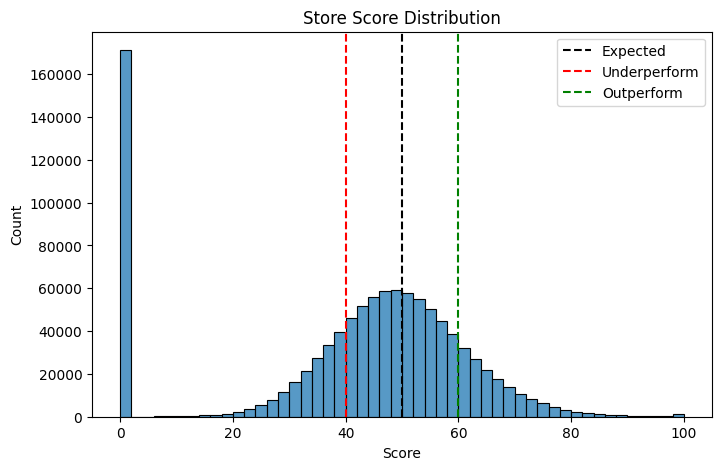

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(train_df["score"], bins=50)

plt.axvline(50, color='black', linestyle='--', label='Expected')
plt.axvline(40, color='red', linestyle='--', label='Underperform')
plt.axvline(60, color='green', linestyle='--', label='Outperform')

plt.title("Store Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend()
plt.show()

performance_label
normal             518247
underperforming    343942
outperforming      155020
Name: count, dtype: int64


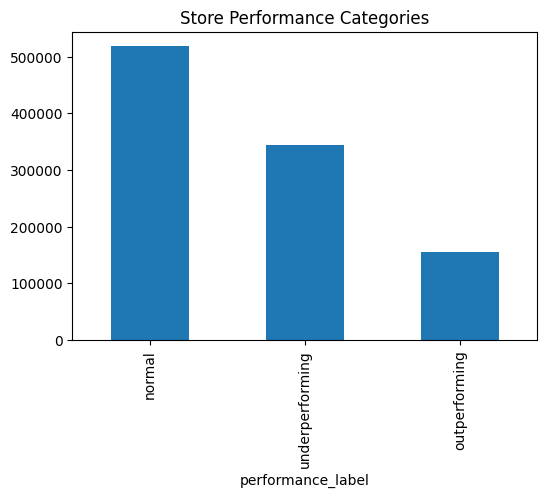

In [85]:
label_counts = train_df["performance_label"].value_counts()

print(label_counts)

label_counts.plot(kind="bar", figsize=(6,4))
plt.title("Store Performance Categories")
plt.show()

In [86]:
top_stores = train_df.groupby("Store")["score"].mean().sort_values(ascending=False).head(10)
worst_stores = train_df.groupby("Store")["score"].mean().sort_values().head(10)

top_df = top_stores.reset_index().rename(columns={"score": "avg_score"})
worst_df = worst_stores.reset_index().rename(columns={"score": "avg_score"})

print("\nTOP STORES:")
print(top_df)

print("\nWORST STORES:")
print(worst_df)


TOP STORES:
   Store  avg_score
0    139  69.380681
1    802  68.787739
2    310  68.566937
3    587  66.113337
4    136  64.332481
5     92  62.995260
6    685  62.130892
7    985  61.368198
8    329  61.210941
9    571  60.897694

WORST STORES:
   Store  avg_score
0    425  14.151254
1    463  18.484528
2    969  18.593924
3    794  18.968034
4    772  20.522796
5    379  21.640797
6    837  21.880376
7    664  22.313428
8    558  22.464961
9    559  22.710469


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


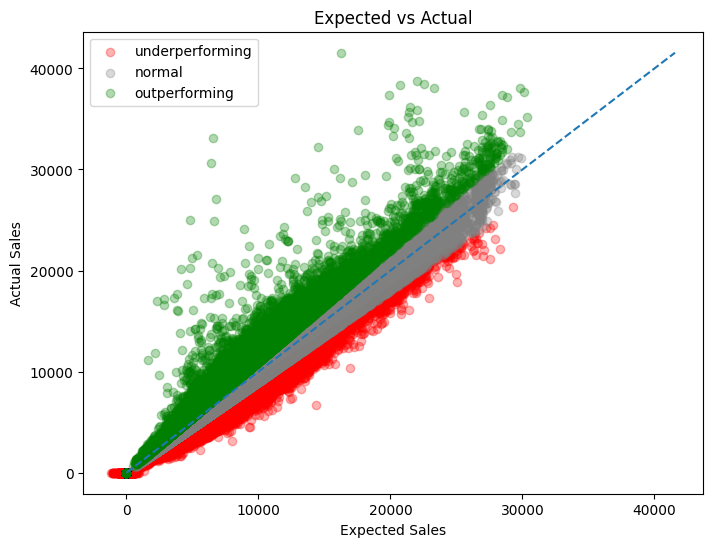

In [87]:
plt.figure(figsize=(8,6))

colors = {
    "underperforming": "red",
    "normal": "gray",
    "outperforming": "green"
}

for label, color in colors.items():
    subset = train_df[train_df["performance_label"] == label]
    plt.scatter(
        subset["expected_sales"],
        subset["Sales"],
        c=color,
        label=label,
        alpha=0.3
    )

max_val = train_df["Sales"].max()

plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("Expected Sales")
plt.ylabel("Actual Sales")
plt.title("Expected vs Actual")
plt.legend()
plt.show()

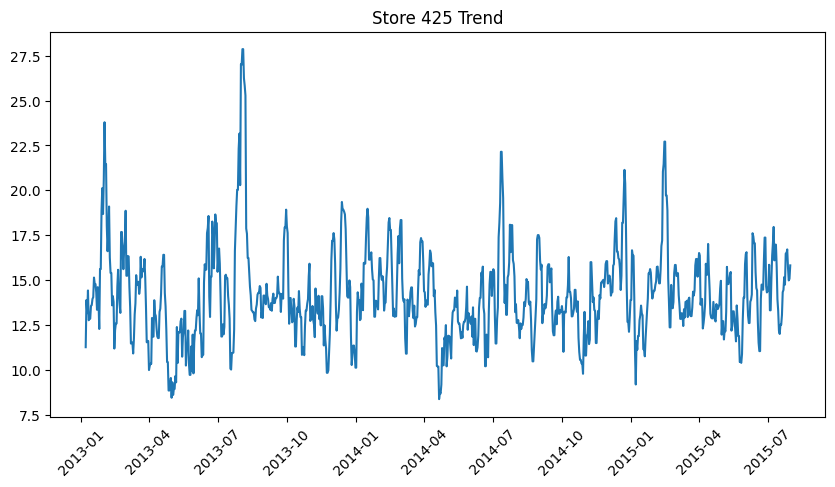

In [88]:
store_id = worst_stores.index[0]

store_data = train_df[train_df["Store"] == store_id]

plt.figure(figsize=(10,5))
plt.plot(store_data["Date"], store_data["rolling_score"])

plt.title(f"Store {store_id} Trend")
plt.xticks(rotation=45)
plt.show()

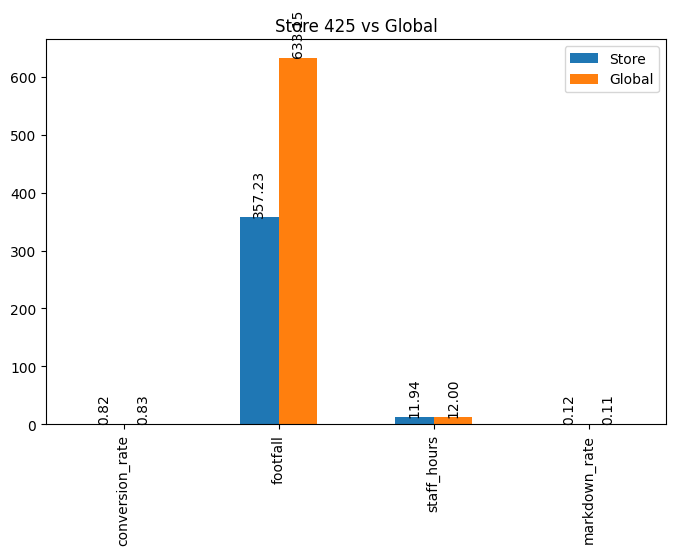

In [89]:
features_to_check = [
    "conversion_rate",
    "footfall",
    "staff_hours",
    "markdown_rate"
]

df_store = train_df[train_df["Store"] == store_id]

comparison = pd.DataFrame({
    "Store": df_store[features_to_check].mean(),
    "Global": train_df[features_to_check].mean()
})

ax = comparison.plot(kind="bar", figsize=(8,5))

plt.title(f"Store {store_id} vs Global")

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            rotation=90
        )

plt.show()

In [94]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,month,year,is_weekend,footfall,conversion_rate,staff_hours,markdown_rate,expected_sales,performance_gap,relative_gap,score,performance_label,rolling_score,trend
1016095,1,2,2013-01-01,0,0,0,0,1,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,-8.439186,-0.000000,10,0.0,-93.539624,93.539624,-1.010806,0.000000,underperforming,NaN,NaN
1014980,1,3,2013-01-02,5530,668,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,656.705107,1.015653,7,0.0,5231.024570,298.975430,0.057143,55.714335,normal,NaN,NaN
1013865,1,4,2013-01-03,4327,578,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,588.316759,0.980797,16,0.0,4522.024565,-195.024565,-0.043118,45.688182,normal,NaN,NaN
1012750,1,5,2013-01-04,4486,619,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,0,618.798132,0.998712,14,0.0,5039.252976,-553.252976,-0.109767,39.023309,underperforming,NaN,NaN
1011635,1,6,2013-01-05,4997,635,1,0,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2013,1,633.497193,1.000792,19,0.0,5289.478314,-292.478314,-0.055284,44.471609,normal,NaN,NaN


In [103]:
# ------------------------------------------
# 1. Compute store-level scores
# ------------------------------------------
store_scores = train_df.groupby("Store")["score"].mean().reset_index()

# Select Top 10 and Bottom 10 stores
top_stores = store_scores.nlargest(10, "score")["Store"]
bottom_stores = store_scores.nsmallest(10, "score")["Store"]

# Filter datasets
df_top = train_df[train_df["Store"].isin(top_stores)]
df_bottom = train_df[train_df["Store"].isin(bottom_stores)]


# ------------------------------------------
# 2. Feature comparison (Top vs Bottom vs Global)
# ------------------------------------------
features = ["conversion_rate", "footfall", "staff_hours", "markdown_rate"]

comparison = pd.DataFrame({
    "Top Stores": df_top[features].mean(),
    "Bottom Stores": df_bottom[features].mean(),
    "Global": train_df[features].mean()
})

print("=== Feature Comparison ===")
print(comparison)


# ------------------------------------------
# 3. Insight generation with differences
# ------------------------------------------
def explain_group_with_diff(df_group, df_global, group_name="Group"):
    """
    Compare group metrics against global averages
    and return human-readable insights with magnitude.
    """
    insights = []

    for col in features:
        group_mean = df_group[col].mean()
        global_mean = df_global[col].mean()
        diff = group_mean - global_mean

        # Business logic:
        # - Lower is bad for most metrics
        # - Higher is bad for markdown_rate
        if col == "markdown_rate":
            if diff > 0:
                insights.append(f"Higher {col} vs global (+{diff:.3f})")
        else:
            if diff < 0:
                insights.append(f"Lower {col} vs global ({diff:.3f})")

    return insights


# ------------------------------------------
# 4. Generate insights
# ------------------------------------------
top_insights = explain_group_with_diff(df_top, train_df, "Top Stores")
bottom_insights = explain_group_with_diff(df_bottom, train_df, "Bottom Stores")


# ------------------------------------------
# 5. Print insights in a clean format
# ------------------------------------------
def print_insights(title, insights):
    print("\n" + "="*30)
    print(title)
    print("="*30)

    if not insights:
        print("No major issues detected")
    else:
        for i in insights:
            print("-", i)


print_insights("🔝 Top Stores Insights", top_insights)
print_insights("🔻 Bottom Stores Insights", bottom_insights)

=== Feature Comparison ===
                 Top Stores  Bottom Stores      Global
conversion_rate    0.837361       0.821589    0.828980
footfall         506.161491     473.050382  633.148832
staff_hours       12.004146      12.087367   11.999458
markdown_rate      0.113745       0.116103    0.114497

🔝 Top Stores Insights
- Lower footfall vs global (-126.987)

🔻 Bottom Stores Insights
- Lower conversion_rate vs global (-0.007)
- Lower footfall vs global (-160.098)
- Higher markdown_rate vs global (+0.002)


In [105]:
# Introduce hierarchical structure (e.g., country and region) to reflect
# real-world retail organization where stores operate within multiple levels
# of business context (store → region → country → market).

# Since the dataset does not provide explicit hierarchy, we simulate it
# to demonstrate how the framework can be extended to multi-level analysis.
train_df["country"] = np.random.choice(["SE", "DE", "FR"], len(train_df))
train_df["region"] = np.random.choice(["North", "South"], len(train_df))

# Aggregate performance at the country level to evaluate how different
# markets perform relative to each other, beyond individual store analysis.
# This enables identifying systemic issues or strengths at higher business levels.
print(train_df.groupby("country")["score"].mean())
print(train_df.groupby("region")["score"].mean())

country
DE    41.357957
FR    41.337310
SE    41.343920
Name: score, dtype: float64
region
North    41.294079
South    41.398830
Name: score, dtype: float64


In [106]:
# Generate a concise summary of the analysis results to support business decision-making.
# This section aggregates key insights into an interpretable format that can be directly
# used in presentations or reports for stakeholders.

print("=== FINAL SUMMARY ===")

# Report total number of unique stores analyzed
# This provides context on the scale of the analysis.
print(f"Total stores: {train_df['Store'].nunique()}")

# Show the distribution of performance categories as percentages
# This helps stakeholders quickly understand how the network is performing overall.
print("\nPerformance distribution:")
print(train_df["performance_label"].value_counts(normalize=True))

# Highlight the main drivers of underperformance identified by the model
# These insights translate analytical results into actionable business recommendations.
print("\nKey drivers of underperformance:")
for i in bottom_insights:
    print("-", i)

=== FINAL SUMMARY ===
Total stores: 1115

Performance distribution:
performance_label
normal             0.509479
underperforming    0.338123
outperforming      0.152397
Name: proportion, dtype: float64

Key drivers of underperformance:
- Lower conversion_rate vs global (-0.007)
- Lower footfall vs global (-160.098)
- Higher markdown_rate vs global (+0.002)
